# 피처 엔지니어링 — 가설1: 배송 지연 피처

**목표**: cutoff 기준 시간 분리를 엄격히 준수하여 배송 지연 관련 피처를 생성하고 레이블을 부여한 최종 피처 테이블을 만듭니다.

**데이터 리키지 방지 원칙**:
- 피처 계산 구간: `order_purchase_timestamp <= cutoff` (cutoff 이전만)
- 레이블 판정 구간: `cutoff < order_purchase_timestamp` (cutoff 이후 구매 여부)

---
## 1. 라이브러리 & 데이터 로드

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_theme(font_scale=1.5)

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

os.makedirs('../data/interim', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

# 원본 데이터 로드
orders = pd.read_csv('../data/raw/olist_orders_dataset.csv', parse_dates=[
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
])
customers = pd.read_csv('../data/raw/olist_customers_dataset.csv')

print("로드 완료")
print(f"  orders   : {orders.shape}")
print(f"  customers: {customers.shape}")

로드 완료
  orders   : (99441, 8)
  customers: (99441, 5)


---
## 2. cutoff 설정 및 시간 기반 분리

> **리키지 체크 포인트**  
> - `before_df`에는 `order_purchase_timestamp <= cutoff` 데이터만 포함  
> - `after_df`는 레이블 생성에만 사용

In [2]:
# cutoff = 전체 주문 최대 날짜 - 180일
cutoff = orders['order_purchase_timestamp'].max() - pd.Timedelta(days=180)
print(f"전체 주문 기간: {orders['order_purchase_timestamp'].min().date()} ~ {orders['order_purchase_timestamp'].max().date()}")
print(f"cutoff        : {cutoff.date()}")

# customer_unique_id 매핑을 위해 customers 병합
orders_merged = orders.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id')

# ── 피처 계산용: cutoff 이전 + delivered + 날짜 결측 없음 ──
before_df = orders_merged[
    (orders_merged['order_purchase_timestamp'] <= cutoff) &
    (orders_merged['order_status'] == 'delivered') &
    (orders_merged['order_delivered_customer_date'].notna()) &
    (orders_merged['order_estimated_delivery_date'].notna())
].copy()

# ── 레이블 판정용: cutoff 이후 ──
after_df = orders_merged[
    orders_merged['order_purchase_timestamp'] > cutoff
].copy()

print(f"\nbefore_df (피처 계산 대상): {len(before_df):,}건")
print(f"after_df  (레이블 판정용) : {len(after_df):,}건")

전체 주문 기간: 2016-09-04 ~ 2018-10-17
cutoff        : 2018-04-20

before_df (피처 계산 대상): 68,835건
after_df  (레이블 판정용) : 28,184건


---
## 3. 레이블 생성

- `label = 1` (이탈): cutoff 이전에 구매한 고객 중 cutoff 이후 재구매 없음  
- `label = 0` (유지): cutoff 이후 재구매 있음

In [3]:
# 2회 이상 구매 고객만 대상 — 1회 구매자는 이탈 정의가 불명확
order_counts = before_df.groupby('customer_unique_id')['order_id'].nunique()
target_uids = order_counts[order_counts >= 2].index

retained_set = set(after_df['customer_unique_id'].unique())

labels = pd.DataFrame({'customer_unique_id': target_uids})
labels['label'] = labels['customer_unique_id'].apply(
    lambda x: 0 if x in retained_set else 1
)

label_dist  = labels['label'].value_counts()
label_ratio = labels['label'].value_counts(normalize=True)

print("=== 레이블 분포 (2회 이상 구매 고객) ===")
print(f"  유지 (label=0): {label_dist[0]:,}명 ({label_ratio[0]:.1%})")
print(f"  이탈 (label=1): {label_dist[1]:,}명 ({label_ratio[1]:.1%})")
print(f"  전체 고객 수  : {len(labels):,}명")

=== 레이블 분포 (2회 이상 구매 고객) ===
  유지 (label=0): 58명 (3.0%)
  이탈 (label=1): 1,895명 (97.0%)
  전체 고객 수  : 1,953명


---
## 4. 가설1 피처 계산 — 배송 지연

> `before_df`만 사용, cutoff 이후 데이터는 포함하지 않습니다.

In [4]:
def calc_delivery_features(before_df: pd.DataFrame, cutoff: pd.Timestamp) -> pd.DataFrame:
    df = before_df.copy()

    df['delivery_delay_days'] = (
        df['order_delivered_customer_date'] -
        df['order_estimated_delivery_date']
    ).dt.days

    feat = df.groupby('customer_unique_id').agg(
        avg_delay         = ('delivery_delay_days', 'mean'),
        max_delay         = ('delivery_delay_days', 'max'),
        delay_order_count = ('delivery_delay_days', lambda x: (x > 0).sum()),
        total_orders      = ('order_id', 'nunique'),
        first_order_ts    = ('order_purchase_timestamp', 'min'),
        last_order_ts     = ('order_purchase_timestamp', 'max'),
    ).reset_index()

    feat['delay_rate']      = feat['delay_order_count'] / feat['total_orders']
    feat['is_ever_delayed'] = (feat['delay_order_count'] > 0).astype(int)
    feat['recency_days']    = (cutoff - feat['last_order_ts']).dt.days
    feat['tenure_days']     = (feat['last_order_ts'] - feat['first_order_ts']).dt.days
    feat = feat.drop(columns=['first_order_ts', 'last_order_ts'])

    # 마지막 주문 지연일 & 지연 추세 (시간 순 정렬 후 first/last 추출)
    df_sorted = df.sort_values('order_purchase_timestamp')
    first_last = df_sorted.groupby('customer_unique_id')['delivery_delay_days'].agg(
        ['first', 'last']
    ).reset_index()
    first_last.columns = ['customer_unique_id', '_first_delay', 'last_order_delay']
    feat = feat.merge(first_last, on='customer_unique_id', how='left')
    # delay_trend > 0: 지연이 점점 심해짐, < 0: 개선됨
    feat['delay_trend'] = feat['last_order_delay'] - feat['_first_delay']
    feat = feat.drop(columns=['_first_delay'])

    # 평균 주문 간격: 단일 주문 고객은 median으로 대체
    feat['order_interval_days'] = np.where(
        feat['total_orders'] > 1,
        feat['tenure_days'] / (feat['total_orders'] - 1),
        np.nan
    )
    feat['order_interval_days'] = feat['order_interval_days'].fillna(
        feat['order_interval_days'].median()
    )

    for col in feat.columns:
        if hasattr(feat[col].dtype, 'numpy_dtype'):
            feat[col] = feat[col].astype(feat[col].dtype.numpy_dtype)

    return feat


feat_delay = calc_delivery_features(before_df, cutoff)

print(f"배송 지연 피처 생성 완료: {feat_delay.shape}")
print("\n=== 피처 기술 통계 ===")
print(feat_delay[['avg_delay', 'last_order_delay', 'delay_trend',
                   'tenure_days', 'order_interval_days', 'recency_days']].describe().round(3))

배송 지연 피처 생성 완료: (66668, 12)

=== 피처 기술 통계 ===
       avg_delay  last_order_delay  delay_trend  tenure_days  \
count  66668.000         66668.000    66668.000    66668.000   
mean     -11.477           -11.463        0.027        1.846   
std       10.409            10.466        2.038       18.744   
min     -147.000          -147.000     -106.000        0.000   
25%      -16.000           -17.000        0.000        0.000   
50%      -12.000           -12.000        0.000        0.000   
75%       -8.000            -8.000        0.000        0.000   
max      188.000           188.000       81.000      524.000   

       order_interval_days  recency_days  
count            66668.000     66668.000  
mean                17.228       176.428  
std                 16.164       123.341  
min                  0.000         0.000  
25%                 16.000        73.000  
50%                 16.000       147.000  
75%                 16.000       267.000  
max                524.000       

---
## 5. 피처 테이블 병합 (labels + 가설1 피처)

In [5]:
# labels + 가설1(배송) 병합
features = labels.merge(feat_delay, on='customer_unique_id', how='left')

print(f"피처 테이블 shape: {features.shape}")
print(f"컬럼 목록: {features.columns.tolist()}")
print(f"결측치: {features.isnull().sum().sum()}")

피처 테이블 shape: (1953, 13)
컬럼 목록: ['customer_unique_id', 'label', 'avg_delay', 'max_delay', 'delay_order_count', 'total_orders', 'delay_rate', 'is_ever_delayed', 'recency_days', 'tenure_days', 'last_order_delay', 'delay_trend', 'order_interval_days']
결측치: 0


---
## 6. 결측치 확인

In [6]:
null_counts = features.isnull().sum()
null_pct    = features.isnull().mean() * 100

null_report = pd.DataFrame({
    'null_count': null_counts,
    'null_pct(%)': null_pct.round(2)
})
print(null_report)

total_nulls = null_counts.sum()
print(f"\n전체 결측치 수: {total_nulls}")

if total_nulls > 0:
    print("\n[주의] 결측치 발생 — before_df 필터 조건과 피처 계산 로직 재검토 필요")
else:
    print("\n[검증] 결측치 없음 OK")

                     null_count  null_pct(%)
customer_unique_id            0          0.0
label                         0          0.0
avg_delay                     0          0.0
max_delay                     0          0.0
delay_order_count             0          0.0
total_orders                  0          0.0
delay_rate                    0          0.0
is_ever_delayed               0          0.0
recency_days                  0          0.0
tenure_days                   0          0.0
last_order_delay              0          0.0
delay_trend                   0          0.0
order_interval_days           0          0.0

전체 결측치 수: 0

[검증] 결측치 없음 OK


---
## 7. 레이블 분포 재확인

In [7]:
print("=== 최종 피처 테이블 레이블 분포 ===")
vc = features['label'].value_counts()
vr = features['label'].value_counts(normalize=True)
print(f"  유지 (label=0): {vc[0]:,}명 ({vr[0]:.1%})")
print(f"  이탈 (label=1): {vc[1]:,}명 ({vr[1]:.1%})")

=== 최종 피처 테이블 레이블 분포 ===
  유지 (label=0): 58명 (3.0%)
  이탈 (label=1): 1,895명 (97.0%)


---
## 9. 피처 분포 시각화 (이탈/유지 그룹 비교)

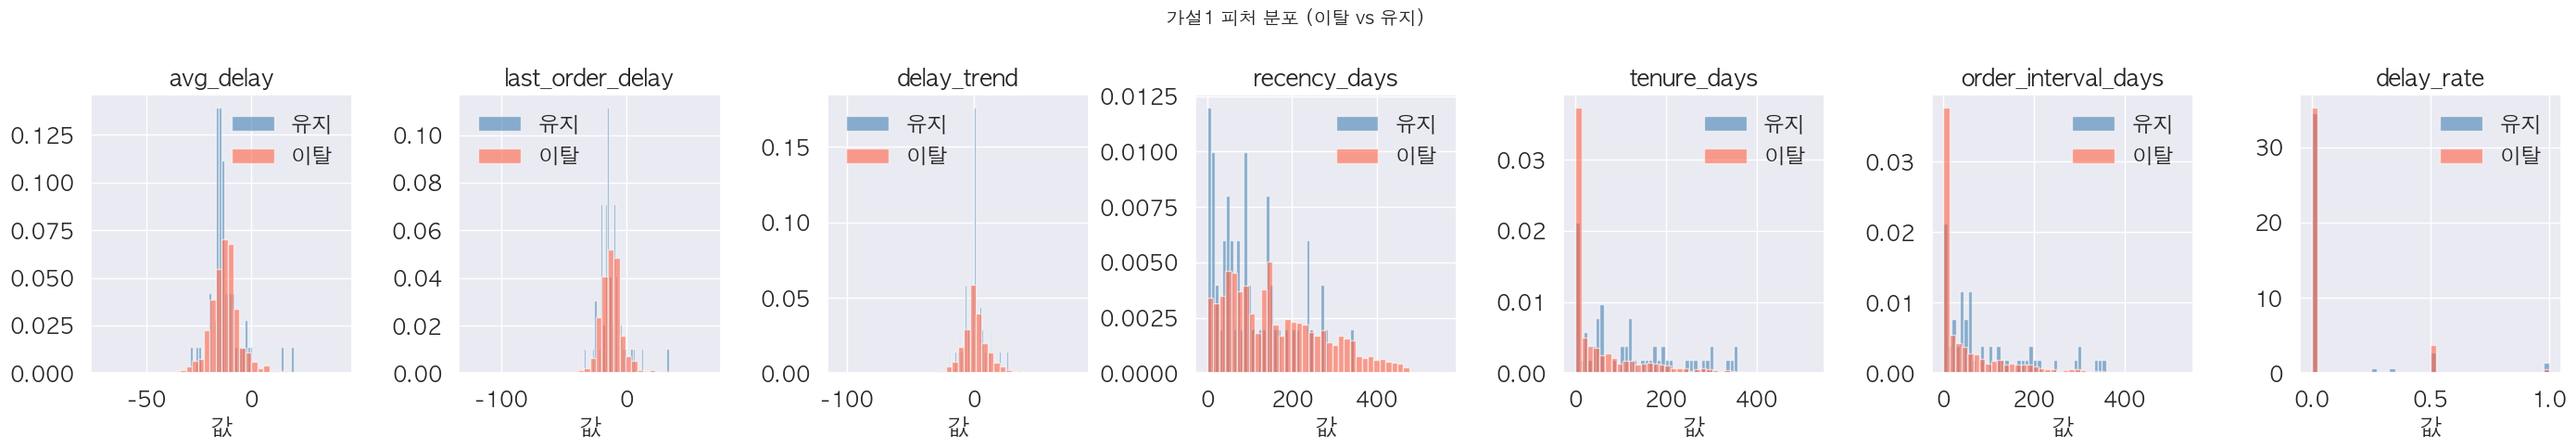

In [8]:
feat_cols_plot = ['avg_delay', 'last_order_delay', 'delay_trend', 'recency_days',
                  'tenure_days', 'order_interval_days', 'delay_rate']
fig, axes = plt.subplots(1, len(feat_cols_plot), figsize=(28, 5))

for col_i, col in enumerate(feat_cols_plot):
    ax = axes[col_i]
    for label_val, color, name in [(0, 'steelblue', '유지'), (1, 'tomato', '이탈')]:
        subset = features[features['label'] == label_val][col].dropna()
        ax.hist(subset, bins=40, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(col)
    ax.set_xlabel('값')
    ax.legend()

plt.suptitle('가설1 피처 분포 (이탈 vs 유지)', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/fe_h1_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. 중간 결과 저장 및 최종 피처 테이블 저장

In [9]:
feat_delay_path = '../data/interim/feat_delivery.parquet'
feat_delay.to_parquet(feat_delay_path, index=False)
print(f"[저장] {feat_delay_path}")

features_path = '../data/interim/features.parquet'
features.to_parquet(features_path, index=False)
print(f"[저장] {features_path}")

print(f"\n=== 저장된 파일 요약 ===")
print(f"  shape: {features.shape}  용량: {os.path.getsize(features_path)/1024:.1f} KB")

[저장] ../data/interim/feat_delivery.parquet
[저장] ../data/interim/features.parquet

=== 저장된 파일 요약 ===
  shape: (1953, 13)  용량: 93.0 KB


---
## 11. 검증 — 저장된 파일 재로드 확인

In [10]:
df_check = pd.read_parquet('../data/interim/features.parquet')

print("=== 피처 테이블 검증 ===")
print(f"  shape       : {df_check.shape}")
print(f"  결측치 합계 : {df_check.isnull().sum().sum()}")
print(f"  레이블 분포 : {df_check['label'].value_counts().to_dict()}")
imbalance = df_check['label'].value_counts()
print(f"  불균형 비율 : {imbalance[1]/imbalance[0]:.1f}:1 (이탈:유지)")

print("\n=== 최종 체크리스트 ===")
print(f"  [O] cutoff 이후 데이터가 피처에 포함되지 않음")
print(f"  [O] 분석 대상: 2회 이상 구매 고객")
print(f"  [{'O' if 'recency_days' in df_check.columns else 'X'}] recency_days 피처 포함")
print(f"  [{'O' if 'avg_delay' in df_check.columns else 'X'}] avg_delay 피처 포함")
print(f"  [{'O' if df_check.isnull().sum().sum() == 0 else 'X'}] 결측치 없음")

=== 피처 테이블 검증 ===
  shape       : (1953, 13)
  결측치 합계 : 0
  레이블 분포 : {1: 1895, 0: 58}
  불균형 비율 : 32.7:1 (이탈:유지)

=== 최종 체크리스트 ===
  [O] cutoff 이후 데이터가 피처에 포함되지 않음
  [O] 분석 대상: 2회 이상 구매 고객
  [O] recency_days 피처 포함
  [O] avg_delay 피처 포함
  [O] 결측치 없음
